# Import Required Libraries
Import the necessary libraries, including pandas, numpy, chemotools, and scikit-learn.

In [19]:
!pip install chemotools

Defaulting to user installation because normal site-packages is not writeable


In [20]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from chemotools.derivative import SavitzkyGolay
from chemotools.scatter import StandardNormalVariate
from chemotools.feature_selection import RangeCut
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA 
from sklearn.cross_decomposition import PLSRegression

# Load Data and first Visualisation
Load the spectra and classes data from the CSV files using pandas.

In [21]:
# Load the spectra data
spectra = pd.read_csv('work/data/spectra_3cl.csv', 
                      sep=';', 
                      index_col=0)

# Load the classes data
labels = pd.read_csv('work/data/labels_3cl.csv',
                     sep=';',
                     index_col=0)
print(labels)

FileNotFoundError: [Errno 2] No such file or directory: 'work/data/spectra_3cl.csv'

In [ ]:
#Explore 

print(f"The spectra dataset has {spectra.shape[0]} samples") 
print(f"The spectra dataset has {spectra.shape[1]} features") 

The spectra dataset has 204 samples
The spectra dataset has 202 features


Text(0.5, 1.0, 'Number of samples per class')

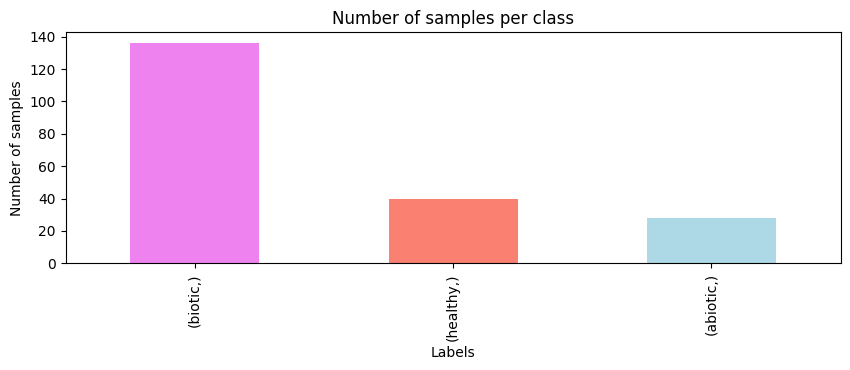

In [ ]:
#plot the sample sizes

fig, ax = plt.subplots(figsize=(10, 3)) 
labels.value_counts().plot.bar(color=['Violet', 'Salmon', 'LightBlue'], ax=ax) 
ax.set_ylabel("Number of samples") 
ax.set_title("Number of samples per class") 


In [ ]:
color_dict = { "biotic": "Violet", "abiotic": "Salmon", "healthy": "LightBlue" } 
labels.iloc[1]

Labels    biotic
Name: 2020-09-10_004, dtype: object

Text(0.5, 1.0, 'Leaf spectra')

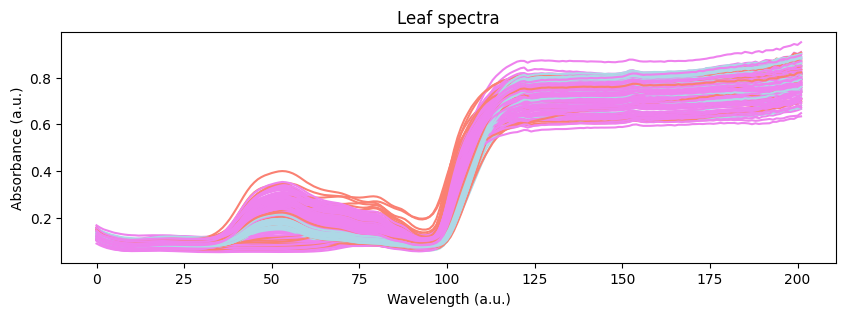

In [ ]:
# define a color dictionary for each origin 
color_dict = { "biotic": "Violet", "abiotic": "Salmon", "healthy": "LightBlue" } 
fig, ax = plt.subplots(figsize=(10, 3)) 
for i, row in enumerate(spectra.iterrows()):
    ax.plot(row[1].values, color=color_dict[labels.iloc[i].values[0]])
ax.set_xlabel("Wavelength (a.u.)") 
ax.set_ylabel("Absorbance (a.u.)") 
ax.set_title("Leaf spectra") 


In [ ]:
# get the values of the spectra and classes
X = spectra.values
# Make a LabelEncoder object 
le = LabelEncoder() 
# Fit the LabelEncoder object 
le.fit(labels.values.ravel()) 
# Transform the labels 
labels_encoded = le.transform(labels.values.ravel()) 
print(labels_encoded)

[1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2
 2 2 2 0 1 0 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1 2 2 2 0 1 0 1 1 0 1 0 1 1 1 1
 1 1 1 1 1 1 1 2 2 2 2 2 2 0 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2
 2 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1
 1 1 1 1 0 0 0 2 2 2 2 2 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2
 2 2 2 2 2 2 2 2 1 1 1 1 1 1 0 1 1 1 1]


In [ ]:
# Make a OneHotEncoder object 
enc = OneHotEncoder(handle_unknown='ignore')
# Fit the LabelEncoder object 
enc.fit(labels.values)
# Transform the labels 
labels_dummy = enc.transform(labels.values).toarray()
print(labels_dummy)
print(enc.inverse_transform(labels_dummy))

[[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0.

# PCA

Text(0.5, 1.0, 'PCA scores')

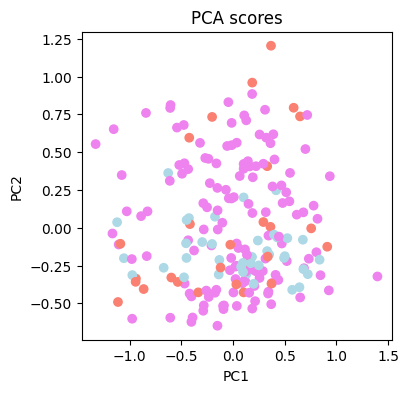

In [ ]:
# standardize the data 
spectra_scaled = StandardScaler(with_std=False).fit_transform(spectra) 
# make a PCA object 
pca = PCA(n_components=2) 
# fit and transform the data 
spectra_pca = pca.fit_transform(spectra_scaled) 
# Make a dataframe with the PCA scores 
spectra_pca_df = pd.DataFrame(data=spectra_pca, columns=["PC1", "PC2"], index=spectra.index) 
# Add the labels to the dataframe 
spectra_pca_df = pd.concat([spectra_pca_df, labels], axis=1) 
# Plot the PCA scores 
fig, ax = plt.subplots(figsize=(4, 4)) 
ax.scatter(spectra_pca_df["PC1"], spectra_pca_df["PC2"], c=spectra_pca_df["Labels"].map(color_dict)) 
ax.set_xlabel("PC1") 
ax.set_ylabel("PC2") 
ax.set_title("PCA scores") 

# Preprocess Data
## Aim of the Data Pre-Processing

-   **Noisy signal**: this noise may be due to measurement or environmental error. The simplest way to eliminate it is to make *m*
    repeated measurements of the spectrum per individual and then calculate an average spectrum per individual.

-   **Signal derivatives**: Using spectrum derivatives can remove additive (measurement bias) or multiplicative effects.

-   **Individual variations**: the dispersion of spectrum measurements between individuals may be due to light scattering and variations in
    the effective wavelength. The simplest way to reduce these variations is to centre and reduce the spectrum data for each
    individual.

-   **Normalise each wavelength**: we can use the raw values of the wavelengths but it is recommanded to centre and reduce each wavelength before the PLS.

## Preprocess the spectra data using chemotools' Savitzky-Golay filter.

In [ ]:
# Create a preprocessing pipeline
pipeline = make_pipeline(
    StandardNormalVariate(),
    SavitzkyGolay(window_size=21, 
                  polynomial_order=11,
                  derivate_order=3),
#    RangeCut(start=0, end=190),
#    StandardScaler(with_std=False)
)
preprocessed_spectra = pipeline.fit_transform(spectra) 

Text(0.5, 1.0, 'Leaf spectra')

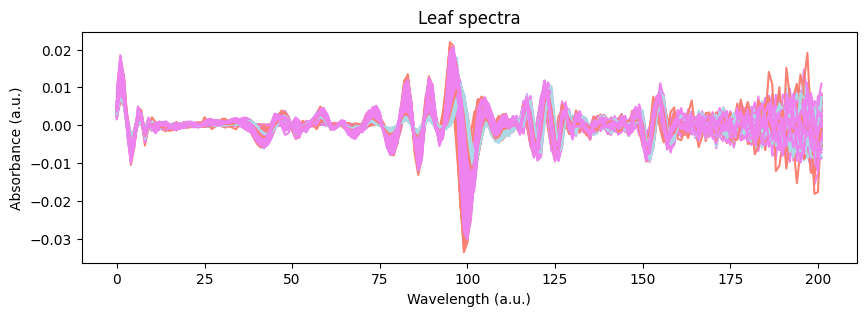

In [ ]:
# Let's plot the preprocessed spectra to see the effect of the preprocessing steps. 
fig, ax = plt.subplots(figsize=(10, 3)) 
for i, spectrum in enumerate(preprocessed_spectra): 
    ax.plot(spectrum, color=color_dict[labels.iloc[i].values[0]])
ax.set_xlabel("Wavelength (a.u.)") 
ax.set_ylabel("Absorbance (a.u.)") 
ax.set_title("Leaf spectra") 

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=52285e31-ca1b-4138-adce-00a746385bb7' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>